# 04. Modeling, Evaluation, and Report Figures

Run strict temporal modeling with graph-only, text-only, and hybrid feature sets. Export metrics, feature importance, and report-ready figures.

In [1]:
from pathlib import Path
import importlib
import sys

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent
sys.path.insert(0, str(root))

import src.phase3 as phase3
from src.visualization import export_report_figures
phase3 = importlib.reload(phase3)

phase1_path = root / 'data' / 'processed' / 'phase1_kcore_filtered.csv'
phase3_dir = root / 'data' / 'processed' / 'phase3'
figure_dir = root / 'reports' / 'figures'
phase3_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
phase1_path

WindowsPath('H:/chuong_trinh_hoc_UEH/mon_hoc_ki_6/social_media_data_analysis/Project/Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning/data/processed/phase1_kcore_filtered.csv')

In [2]:
interactions = phase3.load_phase1_interactions(phase1_path)
metrics_frame, importance_frame, splits = phase3.run_phase3_pipeline(interactions)
paths = phase3.export_phase3_outputs(metrics_frame, importance_frame, phase3_dir)
figure_paths = export_report_figures(interactions, metrics_frame, importance_frame, figure_dir)

{
    'train_rows': len(splits.train),
    'validation_rows': len(splits.validation),
    'test_rows': len(splits.test),
    'metric_rows': len(metrics_frame),
    'importance_rows': len(importance_frame),
    'export_paths': {key: str(value) for key, value in paths.items()},
    'figure_count': len(figure_paths),
}

{'train_rows': 25045,
 'validation_rows': 26450,
 'test_rows': 24185,
 'metric_rows': 14,
 'importance_rows': 960,
 'export_paths': {'metrics': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_model_metrics.csv',
  'importance': 'H:\\chuong_trinh_hoc_UEH\\mon_hoc_ki_6\\social_media_data_analysis\\Project\\Explainable_Signed_Link_Prediction_for_Reddit_Inter-Community_Conflict_Warning\\data\\processed\\phase3\\phase3_feature_importance.csv'},
 'figure_count': 7}

In [3]:
metrics_frame.head(29)

,feature_set,model,validation_roc_auc,validation_pr_auc,validation_f1,validation_macro_f1,validation_precision,validation_recall,validation_balanced_accuracy,validation_accuracy,...,test_precision,test_recall,test_balanced_accuracy,test_accuracy,test_threshold,test_tn,test_fp,test_fn,test_tp,n_features
0,hybrid,logistic_regression,0.750656,0.178651,0.259735,0.593345,0.212539,0.333874,0.620478,0.867032,...,0.207578,0.379964,0.635600,0.855572,0.74,20051,2447,1046,641,120
1,graph_only,logistic_regression,0.745769,0.173905,0.251712,0.572790,0.175101,0.447511,0.644575,0.814102,...,0.171077,0.494369,0.657376,0.797643,0.63,18457,4041,853,834,31
2,hybrid,random_forest,0.761705,0.176467,0.258269,0.570178,0.173262,0.507035,0.662651,0.796522,...,0.176622,0.489034,0.659043,0.805334,0.40,18652,3846,862,825,120
3,graph_only,random_forest,0.760790,0.180629,0.267234,0.581516,0.185732,0.476190,0.659687,0.817543,...,0.178600,0.400711,0.631261,0.829646,0.49,19389,3109,1011,676,31
4,text_only,random_forest,0.694329,0.141009,0.207943,0.546313,0.143385,0.378247,0.604252,0.798677,...,0.155135,0.384114,0.613628,0.811123,0.36,18969,3529,1039,648,89
5,text_only,logistic_regression,0.695449,0.138887,0.219587,0.555189,0.153465,0.385823,0.612979,0.808393,...,0.153277,0.356254,0.604343,0.817821,0.61,19178,3320,1086,601,89
6,hybrid,historical_negative_ratio,0.612496,0.116854,0.220289,0.559405,0.158106,0.363095,0.608932,0.820416,...,0.166117,0.388263,0.621058,0.821377,0.25,19210,3288,1032,655,1
7,graph_only,historical_negative_ratio,0.612496,0.116854,0.220289,0.559405,0.158106,0.363095,0.608932,0.820416,...,0.166117,0.388263,0.621058,0.821377,0.25,19210,3288,1032,655,1
8,hybrid,dummy_prior,0.500000,0.069868,0.130610,0.065305,0.069868,1.000000,0.500000,0.069868,...,0.069754,1.000000,0.500000,0.069754,0.01,0,22498,0,1687,120
9,graph_only,dummy_prior,0.500000,0.069868,0.130610,0.065305,0.069868,1.000000,0.500000,0.069868,...,0.069754,1.000000,0.500000,0.069754,0.01,0,22498,0,1687,31


In [4]:
importance_frame.head(30)

,feature_set,model,feature,importance
480,graph_only,dummy_most_frequent,interaction_count,0.0
481,graph_only,dummy_most_frequent,positive_count,0.0
482,graph_only,dummy_most_frequent,negative_count,0.0
483,graph_only,dummy_most_frequent,sentiment_balance,0.0
484,graph_only,dummy_most_frequent,negative_ratio,0.0
485,graph_only,dummy_most_frequent,reciprocal_edge,0.0
486,graph_only,dummy_most_frequent,source_in_degree,0.0
487,graph_only,dummy_most_frequent,source_out_degree,0.0
488,graph_only,dummy_most_frequent,source_total_degree,0.0
489,graph_only,dummy_most_frequent,source_in_positive_degree,0.0


## Direct Report Figures

The generated report figures are displayed below so the notebook is self-contained for review.

model_comparison_pr_auc.png


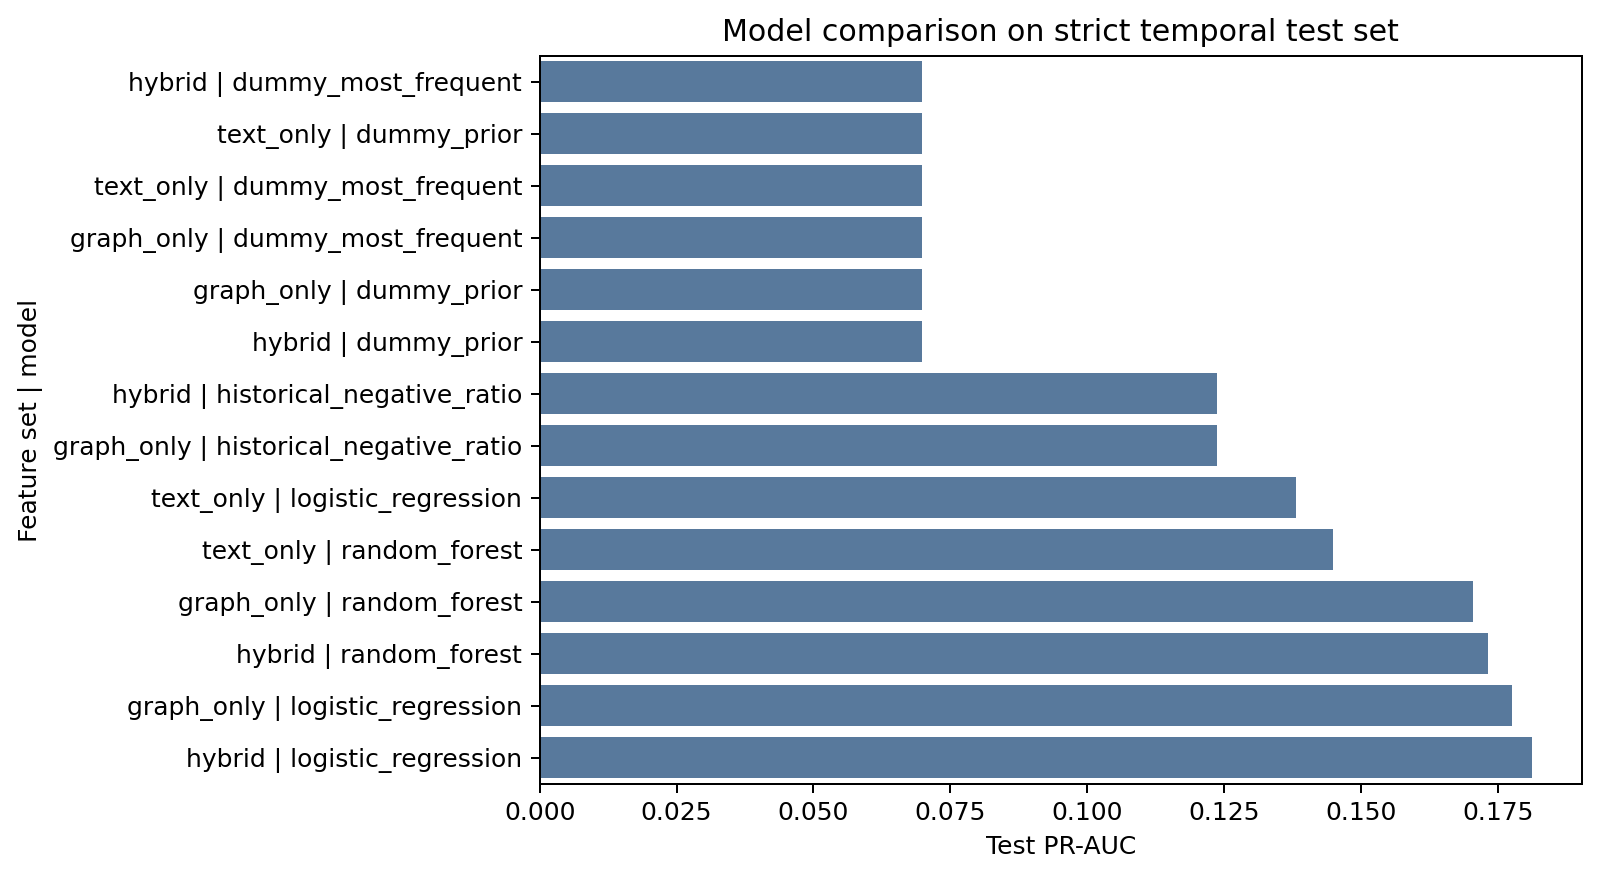

best_confusion_matrix.png


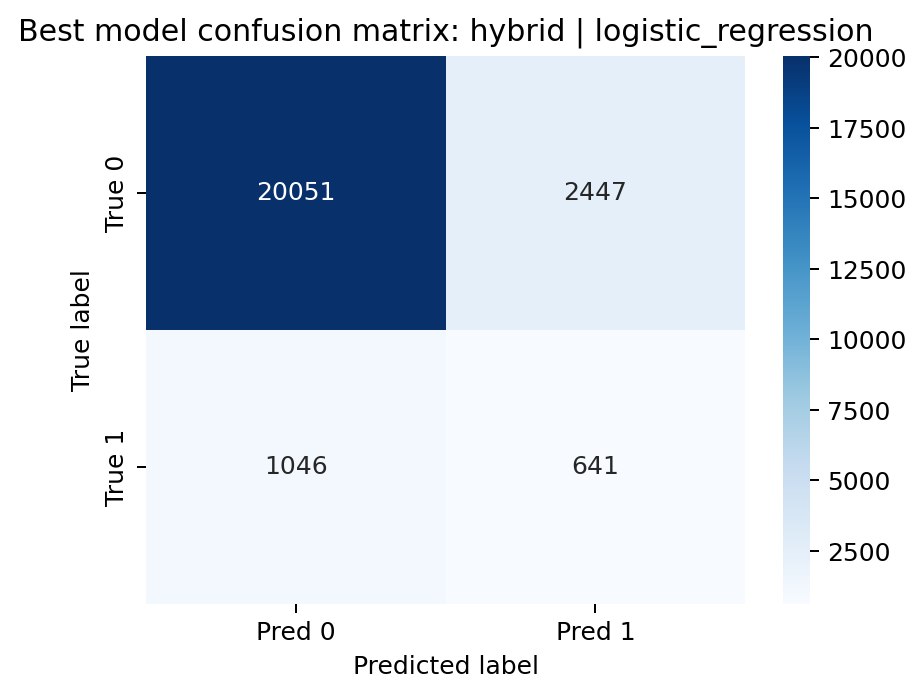

feature_importance_top20.png


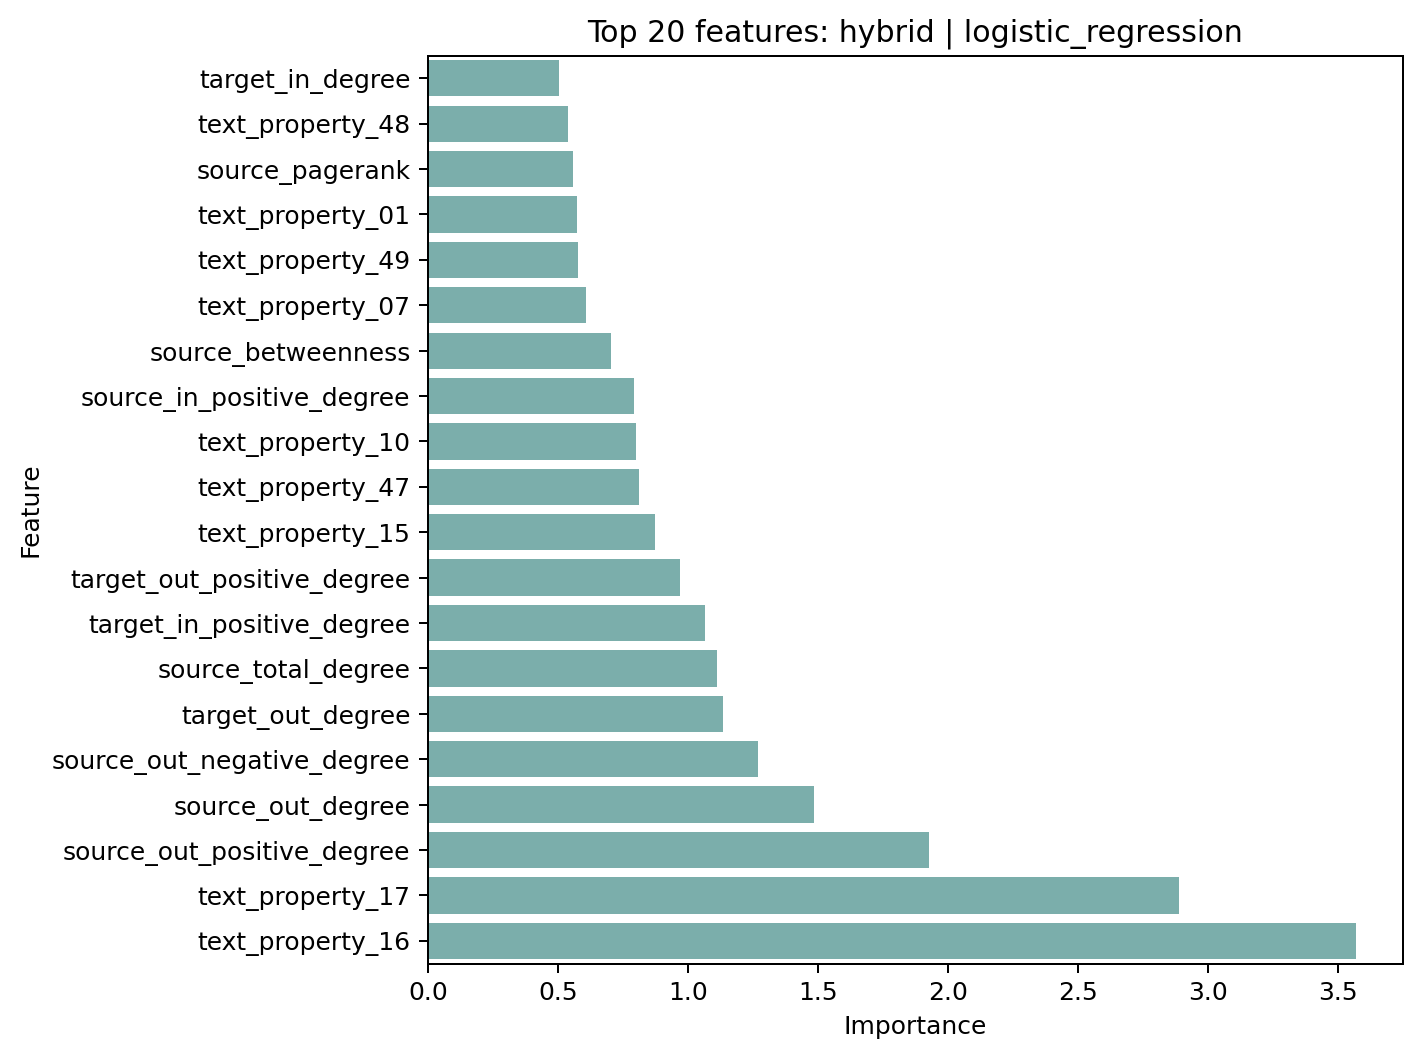

label_distribution.png


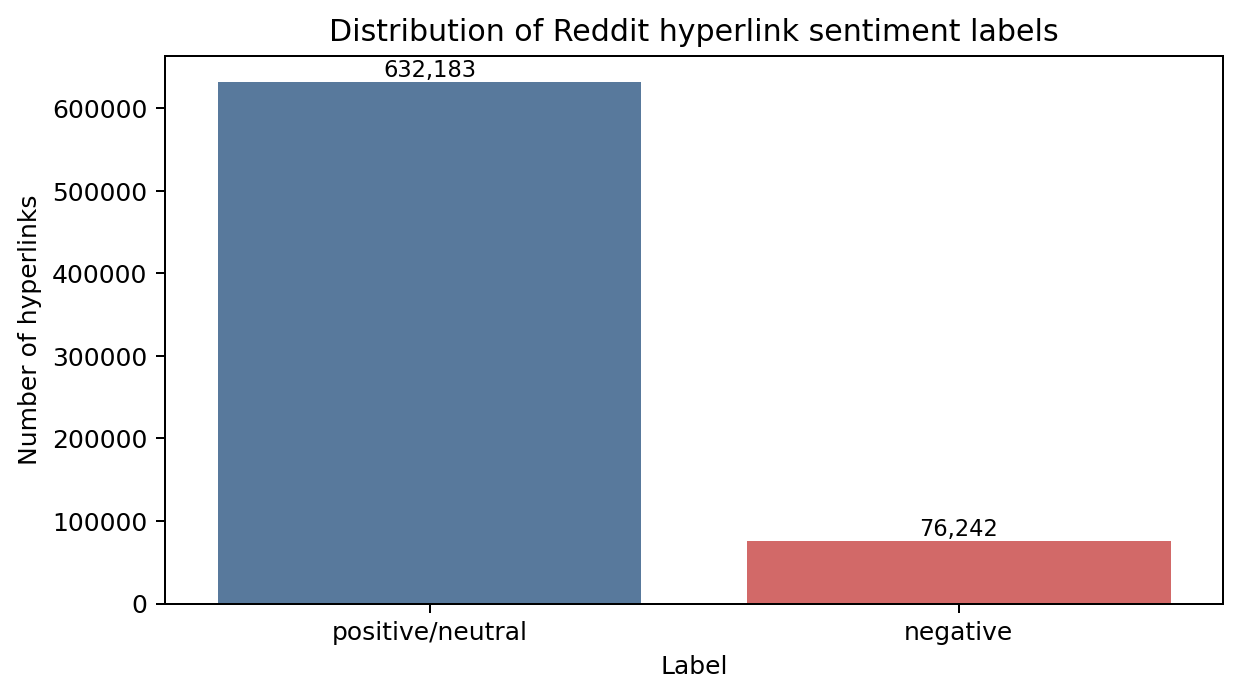

monthly_negative_ratio.png


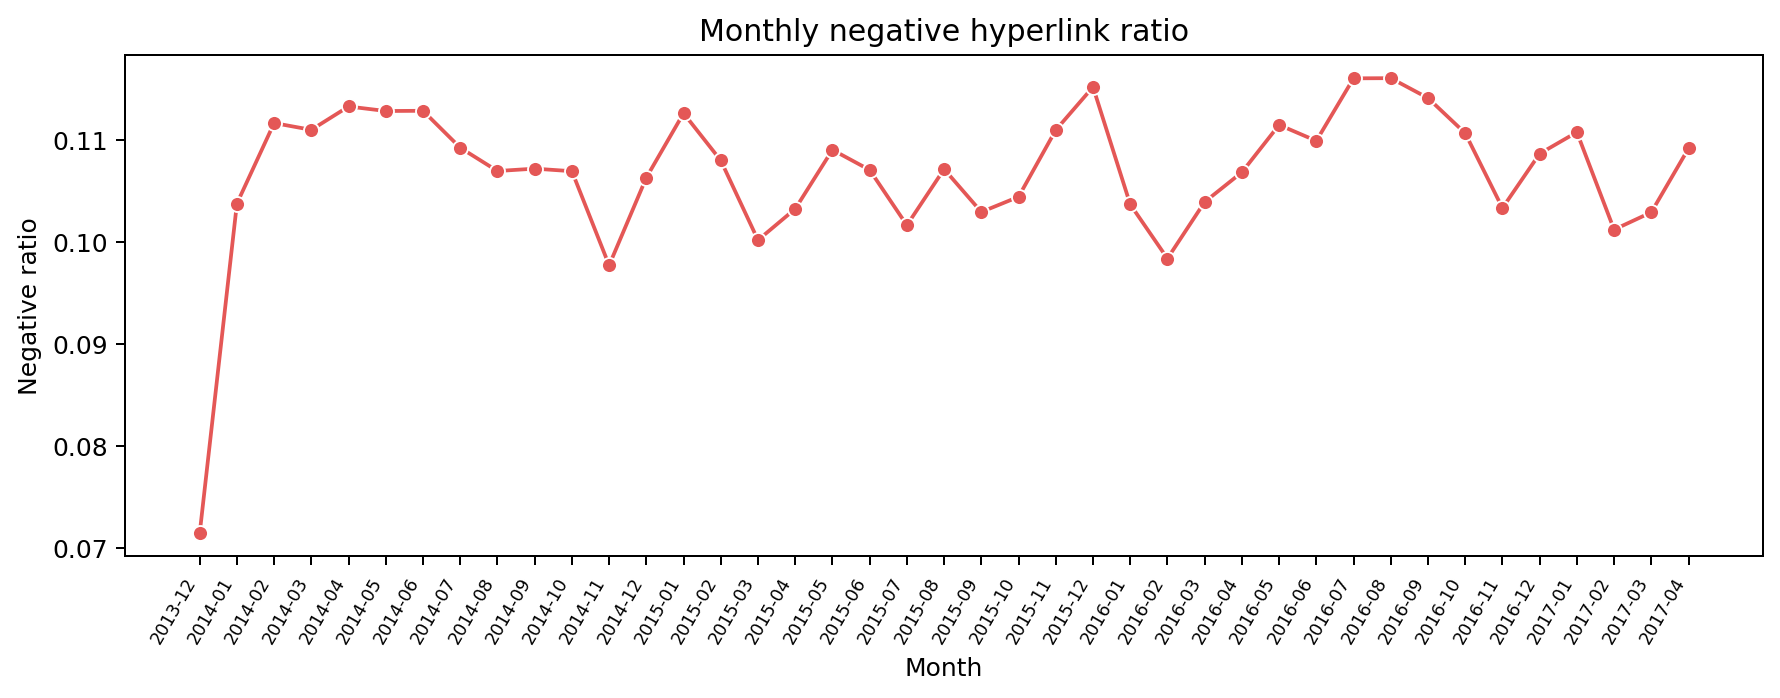

top_negative_sources.png


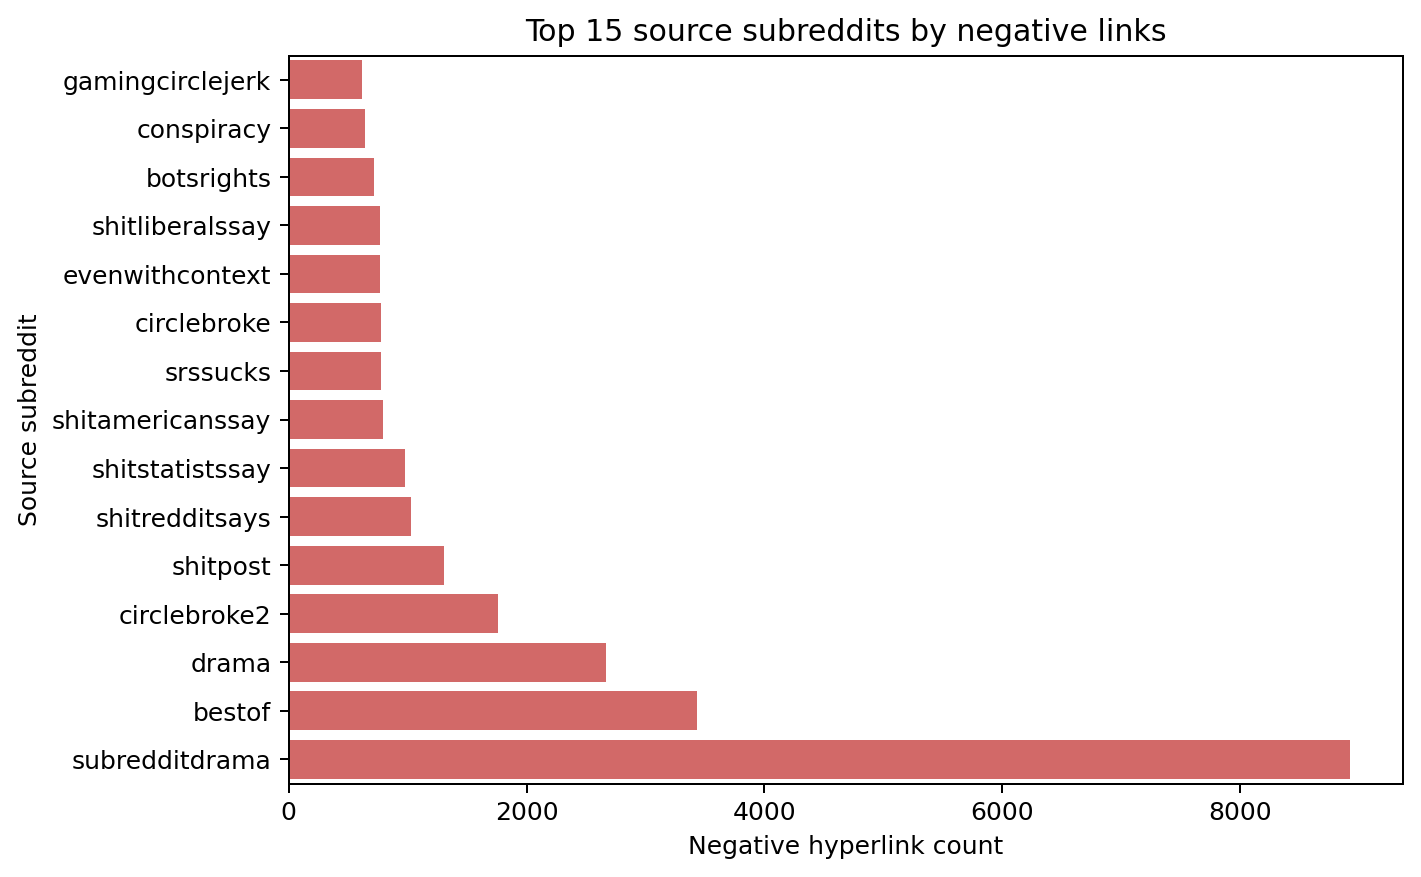

top_negative_targets.png


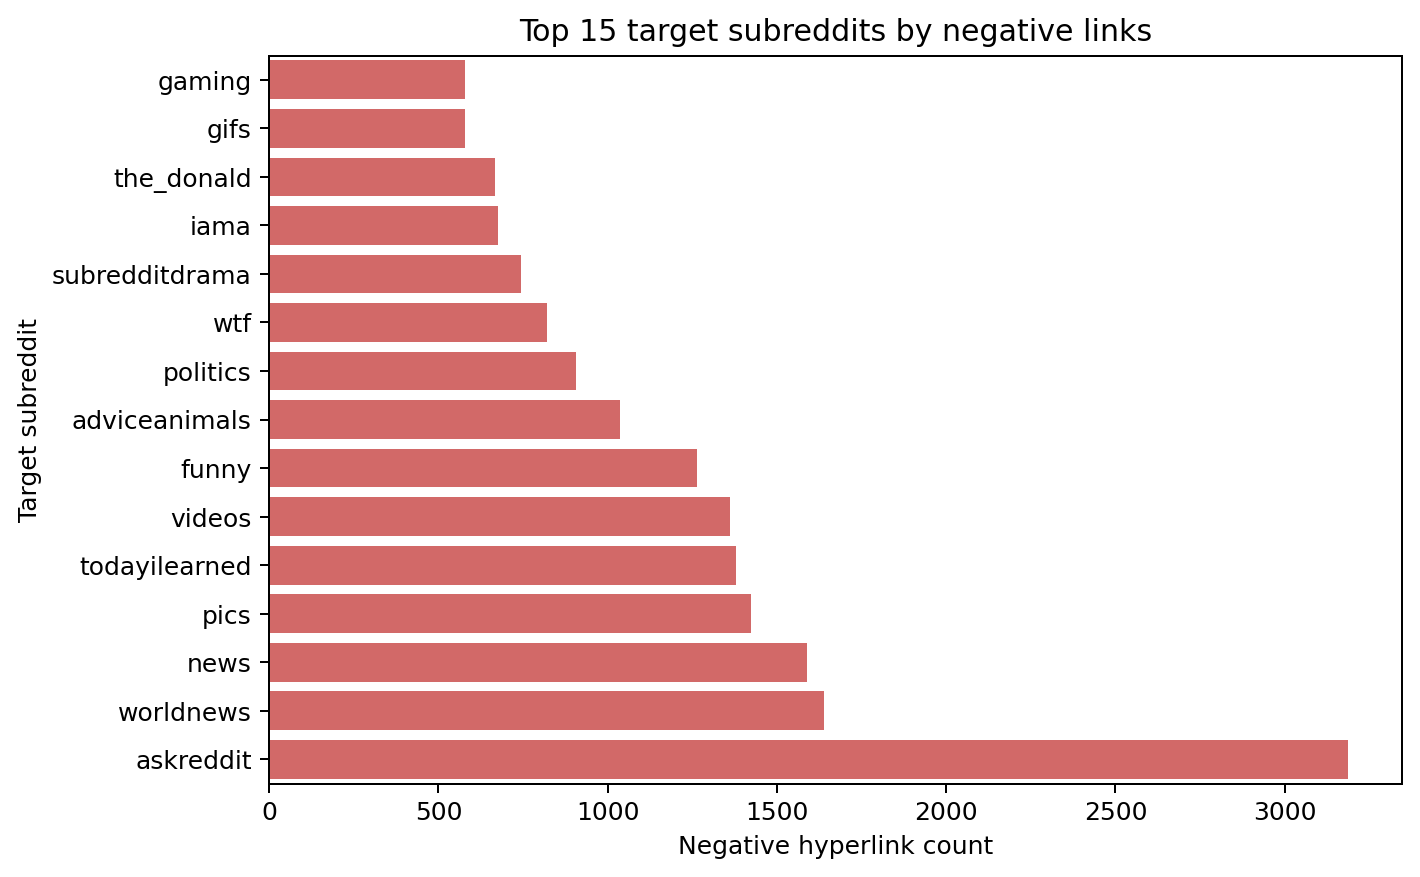

degree_distribution.png


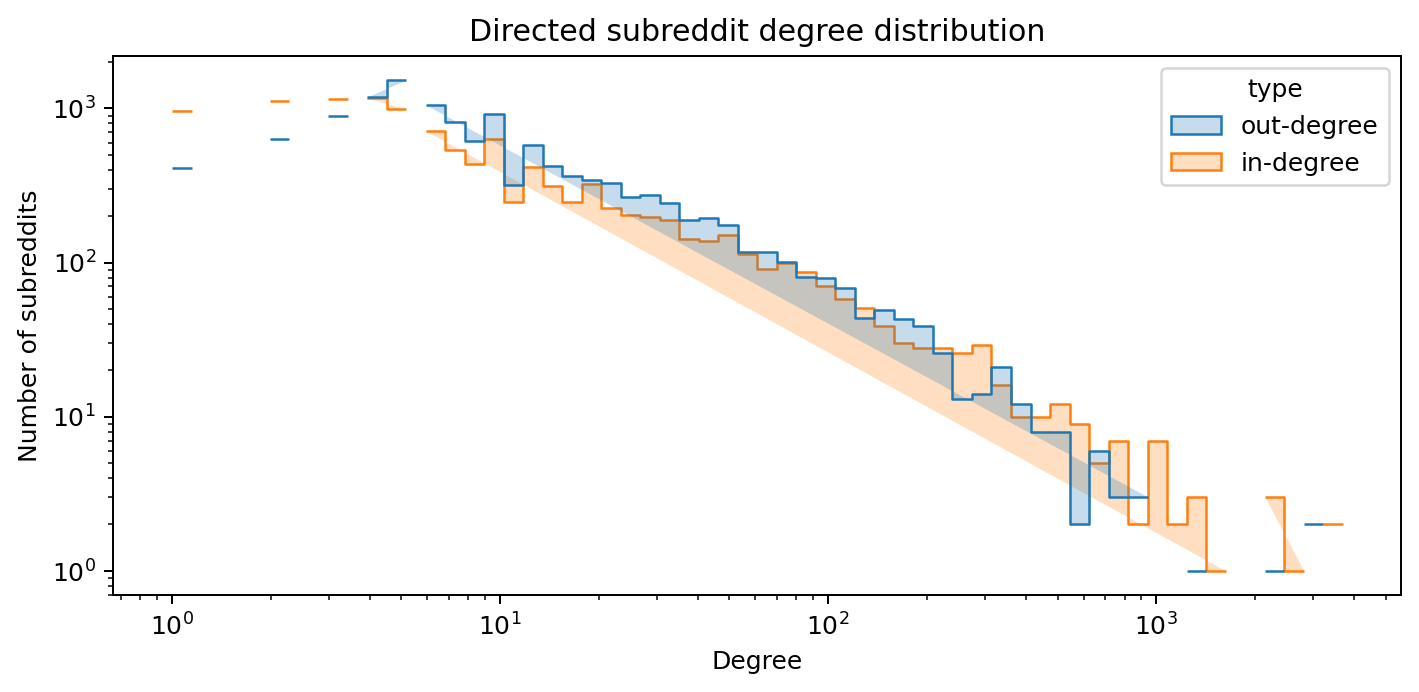

In [5]:
from IPython.display import display, Image

for image_name in [
    'model_comparison_pr_auc.png',
    'best_confusion_matrix.png',
    'feature_importance_top20.png',
    'label_distribution.png',
    'monthly_negative_ratio.png',
    'top_negative_sources.png',
    'top_negative_targets.png',
    'degree_distribution.png',
]:
    path = figure_dir / image_name
    print(path.name)
    display(Image(filename=str(path)))